# 0.1 Polymarket: Descriptive Analysis

Explores daily **prediction-market win probabilities** for Trump and Harris
over the 2024 US election campaign (5 Jul – 4 Nov 2024).

**Input:** `Data/1_Bronze/Polymarket/polymarket_win_probabilities.csv`


<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Win Probabilities Over Time](#1-win-probabilities-over-time)
- [2. Trump – Harris Spread](#2-trump-harris-spread)
- [3. Probability Around Key Events](#3-probability-around-key-events)
- [4. Event Summary Table](#4-event-summary-table)
- [Presentation Purposes](#presentation-purposes)
  - [Win Probabilities — Presentation Chart](#win-probabilities-presentation-chart)
  - [Animation Snapshots — 4 Keyframes](#animation-snapshots-4-keyframes)


## Setup

In [ ]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
from pathlib import Path

sys.path.insert(0, '../..')
from house_style import *
apply_style()

In [2]:
df = pd.read_csv(
    Path('../../data/1_bronze/polymarket/polymarket_win_probabilities.csv'),
    parse_dates=['date']
).sort_values('date').reset_index(drop=True)

# Limit to campaign period (5 Jul – 4 Nov 2024), consistent with other notebooks
df = df[df['date'] <= '2024-11-04'].reset_index(drop=True)

# 7-day rolling averages
df['trump_7d']  = df['Trump (%)'].rolling(7, min_periods=1).mean()
df['harris_7d'] = df['Harris (%)'].rolling(7, min_periods=1).mean()
df['spread']    = df['Trump (%)'] - df['Harris (%)']   # >0 means Trump leads

print(f"Rows : {len(df)}")
print(f"Range: {df['date'].min().date()}  to  {df['date'].max().date()}")
df.describe().round(1)

Rows : 123
Range: 2024-07-05  to  2024-11-04


,date,Trump (%),Harris (%),trump_7d,harris_7d,spread
count,123,123.0,123.0,123.0,123.0,123.0
mean,2024-09-04 00:00:00,54.7,41.1,54.7,40.4,13.6
min,2024-07-05 00:00:00,44.3,5.6,45.2,10.4,-9.6
25%,2024-08-04 12:00:00,49.2,37.5,49.4,36.8,-0.2
50%,2024-09-04 00:00:00,52.5,46.0,51.6,46.6,6.9
75%,2024-10-04 12:00:00,60.5,49.4,61.5,49.1,23.6
max,2024-11-04 00:00:00,70.5,53.9,67.1,52.3,64.4
std,NaN,6.6,12.3,6.4,12.7,18.3


## 1. Win Probabilities Over Time

Raw daily values (faint) and 7-day rolling average (solid). Shaded area highlights which candidate leads. Dashed lines mark the six key political events.

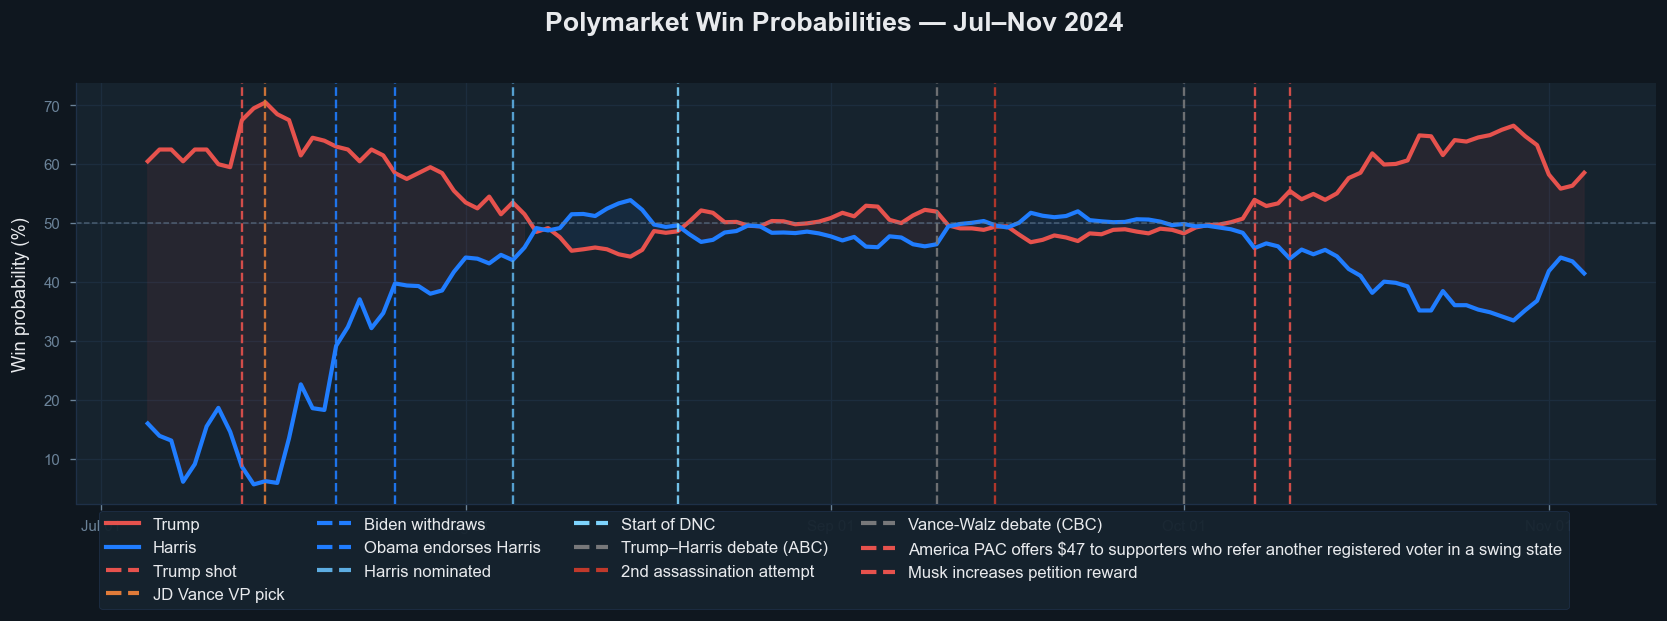

In [3]:
fig, ax = styled_fig(figsize=(14, 5), title='Polymarket Win Probabilities — Jul–Nov 2024')

ax.plot(df['date'], df['Trump (%)'],  color=REPUBLICAN, linewidth=2.5, label='Trump')
ax.plot(df['date'], df['Harris (%)'], color=DEMOCRAT,   linewidth=2.5, label='Harris')

ax.fill_between(df['date'], df['Trump (%)'], df['Harris (%)'],
                where=df['Trump (%)'] >= df['Harris (%)'],
                color=REPUBLICAN, alpha=0.08)
ax.fill_between(df['date'], df['Trump (%)'], df['Harris (%)'],
                where=df['Trump (%)'] < df['Harris (%)'],
                color=DEMOCRAT, alpha=0.08)

ax.axhline(50, color=TEXT_MUTED, linestyle='--', linewidth=0.9, alpha=0.6)

add_events(ax)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
style_ax(ax, ylabel='Win probability (%)', grid_axis='y')

data_handles = [
    mlines.Line2D([], [], color=REPUBLICAN, linewidth=2.5, label='Trump'),
    mlines.Line2D([], [], color=DEMOCRAT,   linewidth=2.5, label='Harris'),
]
fig.legend(
    handles=data_handles + event_legend_handles(),
    loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=4, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
    labelcolor=TEXT_PRIMARY, fontsize=10, framealpha=0.95
)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

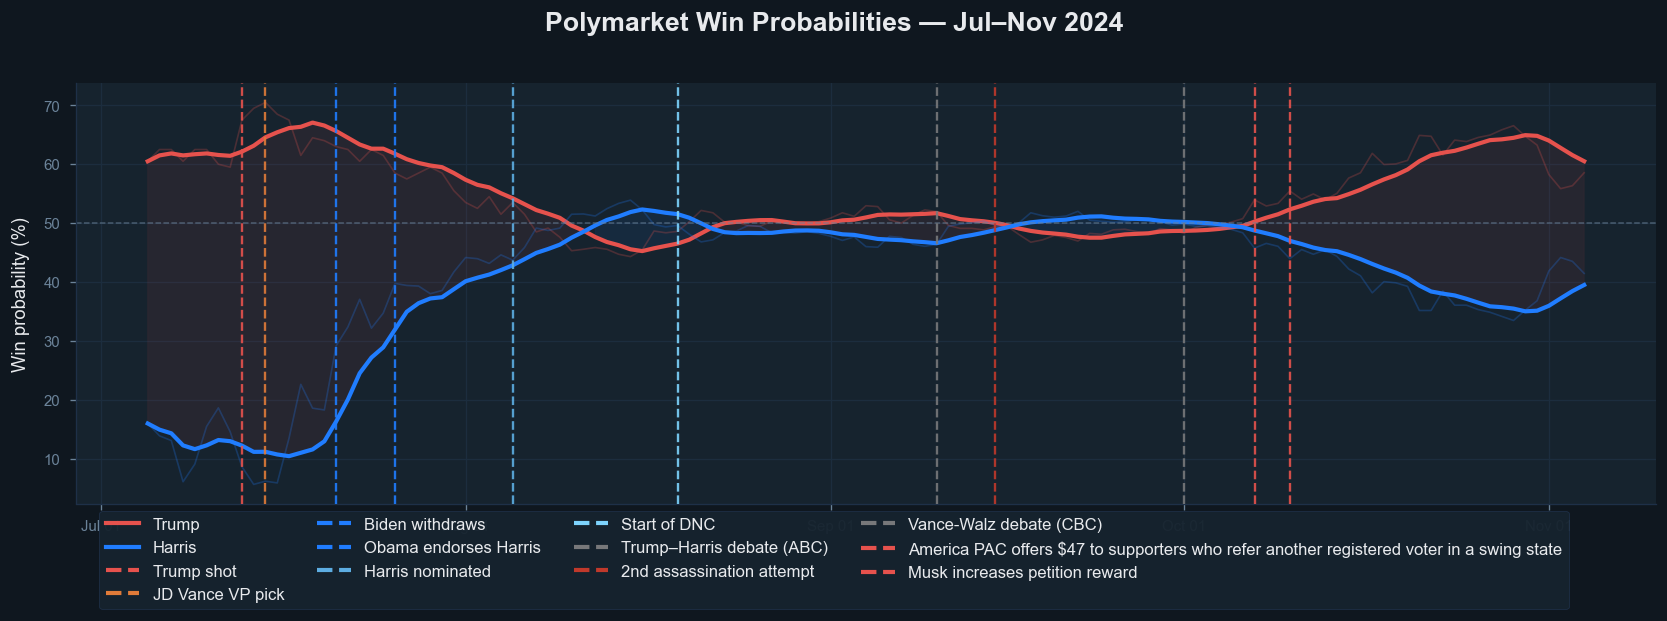

In [4]:
fig, ax = styled_fig(figsize=(14, 5), title='Polymarket Win Probabilities — Jul–Nov 2024')

# Raw daily (faint) + 7-day rolling (solid)
ax.plot(df['date'], df['Trump (%)'],  color=REPUBLICAN, alpha=0.25, linewidth=1)
ax.plot(df['date'], df['trump_7d'],   color=REPUBLICAN, linewidth=2.5, label='Trump (7d MA)')
ax.plot(df['date'], df['Harris (%)'], color=DEMOCRAT,   alpha=0.25, linewidth=1)
ax.plot(df['date'], df['harris_7d'],  color=DEMOCRAT,   linewidth=2.5, label='Harris (7d MA)')
ax.fill_between(df['date'], df['trump_7d'], df['harris_7d'],
                where=df['trump_7d'] >= df['harris_7d'],
                color=REPUBLICAN, alpha=0.08)
ax.fill_between(df['date'], df['trump_7d'], df['harris_7d'],
                where=df['trump_7d'] < df['harris_7d'],
                color=DEMOCRAT, alpha=0.08)
ax.axhline(50, color=TEXT_MUTED, linestyle='--', linewidth=0.9, alpha=0.6)

add_events(ax)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
style_ax(ax, ylabel='Win probability (%)', grid_axis='y')

data_handles = [
    mlines.Line2D([], [], color=REPUBLICAN, linewidth=2.5, label='Trump'),
    mlines.Line2D([], [], color=DEMOCRAT,   linewidth=2.5, label='Harris'),
]
fig.legend(
    handles=data_handles + event_legend_handles(),
    loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=4, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
    labelcolor=TEXT_PRIMARY, fontsize=10, framealpha=0.95
)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

## 2. Trump – Harris Spread

Positive = Trump leads; negative = Harris leads. Shows how the gap evolved across the campaign.

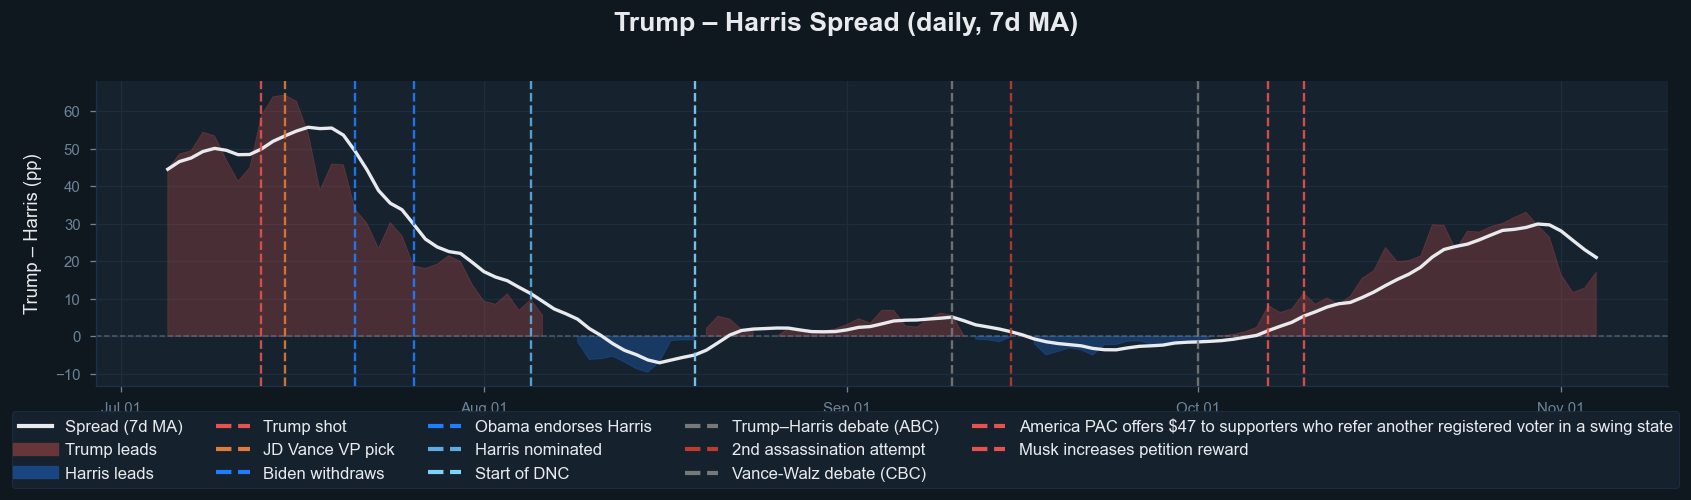

In [9]:
fig, ax = styled_fig(figsize=(14, 4), title='Trump – Harris Spread (daily, 7d MA)')

ax.axhline(0, color=TEXT_MUTED, linestyle='--', linewidth=0.9, alpha=0.6)
ax.fill_between(df['date'], df['spread'], 0,
                where=df['spread'] >= 0, color=REPUBLICAN, alpha=0.25, label='Trump leads')
ax.fill_between(df['date'], df['spread'], 0,
                where=df['spread'] < 0,  color=DEMOCRAT,   alpha=0.25, label='Harris leads')
spread_7d = df['spread'].rolling(7, min_periods=1).mean()
ax.plot(df['date'], spread_7d, color=TEXT_PRIMARY, linewidth=2, label='Spread (7d MA)')

add_events(ax)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
style_ax(ax, ylabel='Trump – Harris (pp)', grid_axis='y')

fig.legend(
    handles=[
        mlines.Line2D([], [], color=TEXT_PRIMARY, linewidth=2.5, label='Spread (7d MA)'),
        mlines.Line2D([], [], color=REPUBLICAN, linewidth=8, alpha=0.4, label='Trump leads'),
        mlines.Line2D([], [], color=DEMOCRAT,   linewidth=8, alpha=0.4, label='Harris leads'),
    ] + event_legend_handles(),
    loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=5, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
    labelcolor=TEXT_PRIMARY, fontsize=10, framealpha=0.95
)
plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()

## 3. Probability Around Key Events

Each candidate's probability indexed to 100 on the event day, shown over a ±7-day window. Reveals how markets reacted to each political shock.

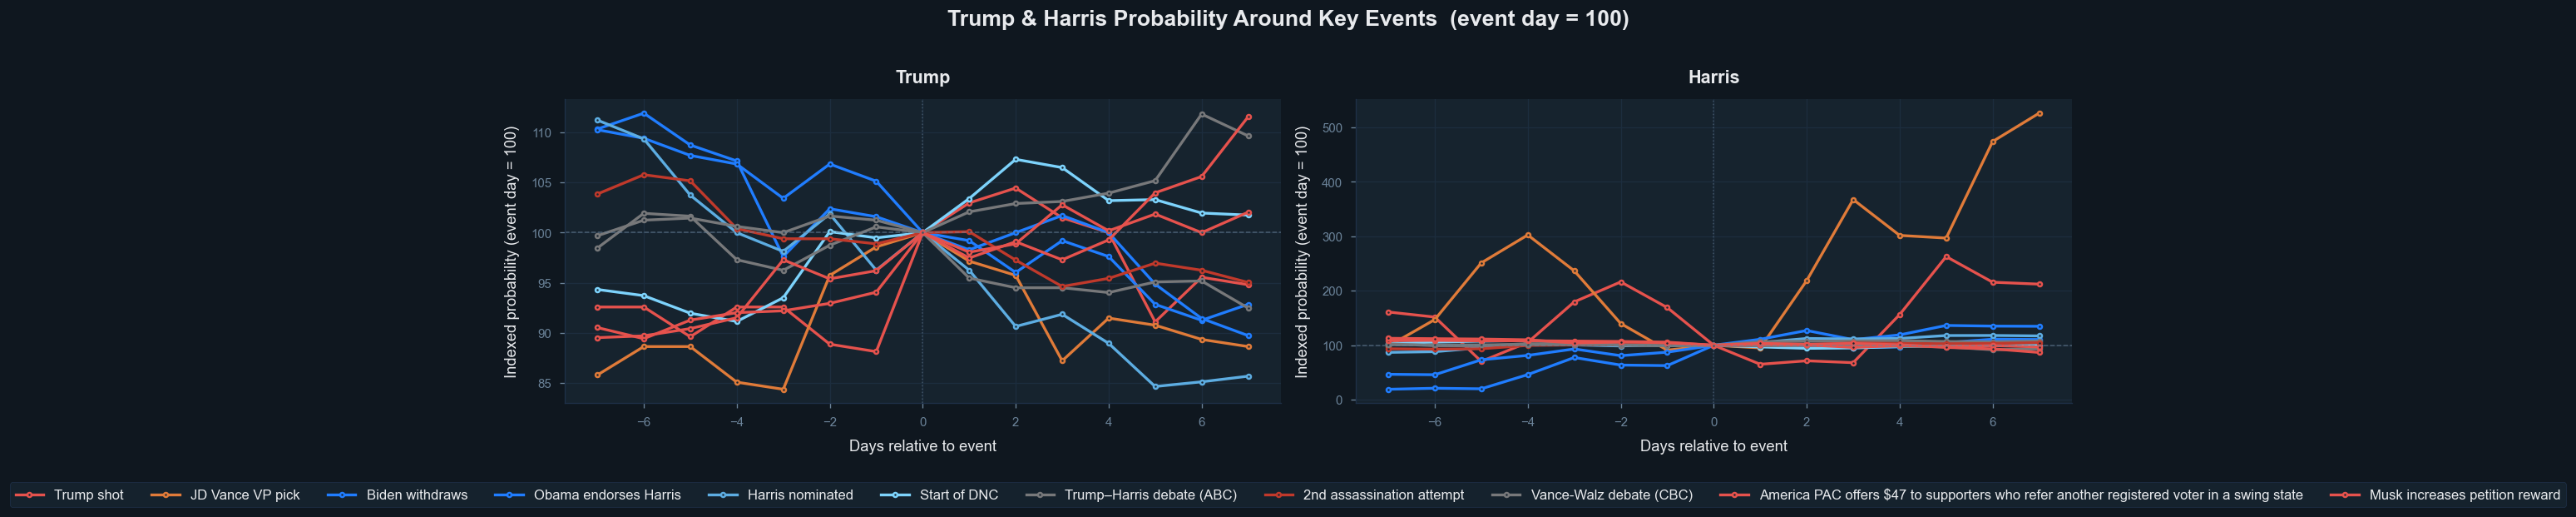

In [10]:
# Win probability in a ±7-day window around each key event, indexed to event day = 100
def index_around(col, event_date_str, days=7):
    ev  = pd.Timestamp(event_date_str)
    win = df[(df['date'] >= ev - pd.Timedelta(days=days)) &
             (df['date'] <= ev + pd.Timedelta(days=days))].copy().reset_index(drop=True)
    base_idx = (win['date'] - ev).abs().idxmin()
    base     = win.loc[base_idx, col]
    if base == 0:
        return None, None
    rel  = (win['date'] - ev).dt.days.values
    vals = (win[col] / base * 100).values
    return rel, vals

fig, axes = styled_fig(nrows=1, ncols=2, figsize=(16, 5),
                       title='Trump & Harris Probability Around Key Events  (event day = 100)')

legend_handles = None

for ax_i, (col, cand_color, label) in enumerate([
    ('Trump (%)',  REPUBLICAN, 'Trump'),
    ('Harris (%)', DEMOCRAT,   'Harris'),
]):
    ax = axes[ax_i]
    handles = []
    for ev_lbl, ev_date, ev_color in EVENTS:
        rel, vals = index_around(col, ev_date)
        if rel is None:
            continue
        line, = ax.plot(rel, vals, color=ev_color, linewidth=2, label=ev_lbl,
                marker='o', markersize=3,
                markerfacecolor=BG_PANEL, markeredgecolor=ev_color, markeredgewidth=1.5)
        handles.append(line)
    ax.axhline(100, color=TEXT_MUTED, linestyle='--', linewidth=0.9, alpha=0.6)
    ax.axvline(0,   color=TEXT_MUTED, linestyle=':',  linewidth=0.9, alpha=0.5)
    style_ax(ax, xlabel='Days relative to event',
             ylabel='Indexed probability (event day = 100)', title=label)
    if legend_handles is None:
        legend_handles = handles  # collect once — same events for both panels

fig.legend(
    handles=legend_handles,
    loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=len(legend_handles), facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
    labelcolor=TEXT_PRIMARY, fontsize=10, framealpha=0.95
)
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

## 4. Event Summary Table

Win probability for each candidate the day before and the day after each key event.

In [11]:
def prob_on(offset, date_str):
    ev     = pd.Timestamp(date_str)
    target = ev + pd.Timedelta(days=offset)
    match  = df[df['date'] >= target] if offset >= 0 else df[df['date'] <= target]
    if match.empty:
        return None, None
    row = match.iloc[0] if offset >= 0 else match.iloc[-1]
    return round(row['Trump (%)'], 1), round(row['Harris (%)'], 1)

rows = []
for lbl, date, _ in EVENTS:
    t_m1, h_m1 = prob_on(-1, date)
    t_0,  h_0  = prob_on( 0, date)
    t_p1, h_p1 = prob_on(+1, date)
    rows.append({
        'Event'         : lbl,
        'Date'          : date,
        'Trump day −1'  : t_m1,
        'Harris day −1' : h_m1,
        'Trump day 0'   : t_0,
        'Harris day 0'  : h_0,
        'Trump day +1'  : t_p1,
        'Harris day +1' : h_p1,
        'Δ Trump'       : round(t_p1 - t_m1, 1) if (t_m1 and t_p1) else None,
        'Δ Harris'      : round(h_p1 - h_m1, 1) if (h_m1 and h_p1) else None,
    })

summary = pd.DataFrame(rows).set_index(['Event', 'Date'])

def color_cell(val, col):
    if pd.isna(val): return ''
    if 'Trump'  in col: return f'color: {REPUBLICAN}'
    if 'Harris' in col: return f'color: {DEMOCRAT}'
    return ''

delta_cols = ['Δ Trump', 'Δ Harris']
value_cols = [c for c in summary.columns if c not in delta_cols]

styled = (summary.style
    .format('{:.1f}%',  subset=value_cols, na_rep='—')
    .format('{:+.1f}%', subset=delta_cols, na_rep='—'))

for col in summary.columns:
    styled = styled.map(lambda v, c=col: color_cell(v, c), subset=[col])

styled.set_caption('Polymarket probabilities — day before, event day, and day after each key event')

,,Trump day −1,Harris day −1,Trump day 0,Harris day 0,Trump day +1,Harris day +1,Δ Trump,Δ Harris
Event,Date,,,,,,,,
Trump shot,2024-07-13,59.5%,14.6%,67.5%,8.6%,69.5%,5.6%,+10.0%,-9.0%
JD Vance VP pick,2024-07-15,69.5%,5.6%,70.5%,6.2%,68.5%,5.8%,-1.0%,+0.2%
Biden withdraws,2024-07-21,64.0%,18.2%,63.0%,29.2%,62.5%,32.4%,-1.5%,+14.2%
Obama endorses Harris,2024-07-26,61.5%,34.7%,58.5%,39.8%,57.5%,39.4%,-4.0%,+4.7%
Harris nominated,2024-08-05,51.5%,44.6%,53.5%,43.7%,51.5%,45.8%,+0.0%,+1.2%
Start of DNC,2024-08-19,48.4%,49.4%,48.6%,49.6%,50.2%,48.1%,+1.8%,-1.3%
Trump–Harris debate (ABC),2024-09-10,52.2%,46.0%,52.0%,46.4%,49.6%,49.4%,-2.6%,+3.4%
2nd assassination attempt,2024-09-15,48.8%,50.4%,49.4%,49.6%,49.4%,49.2%,+0.6%,-1.2%
Vance-Walz debate (CBC),2024-10-01,48.8%,49.6%,48.2%,49.8%,49.2%,49.4%,+0.4%,-0.2%


## Presentation Purposes

### Win Probabilities — Presentation Chart

Clean chart with 4 annotated periods and a full event timeline below.


In [ ]:
# ── Events in the bottom timeline strip ───────────────────────────────────────
TIMELINE_EVENTS = [
    ('Trump shot',              '2024-07-13', REPUBLICAN),
    ('Vance VP pick',           '2024-07-15', '#e07b39'),
    ('Biden withdraws',         '2024-07-21', DEMOCRAT),
    ('Obama endorses Harris',   '2024-07-26', DEMOCRAT),
    ('Harris nominated',        '2024-08-05', '#5dade2'),
    ('Trump–Harris debate',     '2024-09-10', NEUTRAL),
    ('2nd assassination att.',  '2024-09-15', '#c0392b'),
    ('Musk · America PAC',      '2024-10-07', '#e07b39'),
    ('Musk increases reward',   '2024-10-10', '#e07b39'),
]

# ── 4 highlighted periods ─────────────────────────────────────────────────────
# ① red (REPUBLICAN), ② blue (DEMOCRAT, wider), ③ grey, ④ darker-red
PERIODS = [
    ('① Trump shot\n& Vance VP',  '2024-07-13', '2024-07-20', REPUBLICAN,  0.14),
    ('② Biden out\nHarris in',    '2024-07-21', '2024-08-20', DEMOCRAT,    0.09),
    ('③ Debate &\n2nd attempt',   '2024-09-10', '2024-09-19', '#6b7280',   0.18),
    ('④ Musk\nmingles',           '2024-10-07', '2024-10-14', '#a83232',   0.15),
]

# ── Figure: main chart (top) + wide event strip (bottom) ─────────────────────
fig = plt.figure(figsize=(17, 10), facecolor=BG_DARK)
gs  = gridspec.GridSpec(
    2, 1,
    height_ratios=[3.6, 1.4],
    hspace=0.0,
    top=0.91, bottom=0.02, left=0.07, right=0.96,
)
ax   = fig.add_subplot(gs[0])
ax_e = fig.add_subplot(gs[1])

ax.set_facecolor(BG_PANEL)
ax_e.set_facecolor(BG_DARK)

DATE_MIN = df['date'].min()
DATE_MAX = df['date'].max()

# ── Shaded period bands ───────────────────────────────────────────────────────
for label, start, end, color, alpha in PERIODS:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    ax.axvspan(s, e, color=color, alpha=alpha, zorder=1, linewidth=0)
    ax_e.axvspan(s, e, color=color, alpha=alpha * 0.5, zorder=1, linewidth=0)
    mid = s + (e - s) / 2
    ax.text(mid, 73.5, label,
            color=color, fontsize=8.5, ha='center', va='bottom',
            fontweight='bold', linespacing=1.4, zorder=6)

# ── Probability lines: raw = thick solid, 7d MA = lighter thin ───────────────
ax.plot(df['date'], df['trump_7d'],   color=REPUBLICAN, alpha=0.35, linewidth=1.4,
        linestyle='--', zorder=2)
ax.plot(df['date'], df['Trump (%)'],  color=REPUBLICAN, linewidth=3.2, zorder=3)
ax.plot(df['date'], df['harris_7d'],  color=DEMOCRAT,   alpha=0.35, linewidth=1.4,
        linestyle='--', zorder=2)
ax.plot(df['date'], df['Harris (%)'], color=DEMOCRAT,   linewidth=3.2, zorder=3)

ax.fill_between(df['date'], df['Trump (%)'], df['Harris (%)'],
                where=df['Trump (%)'] >= df['Harris (%)'],
                color=REPUBLICAN, alpha=0.07, zorder=2)
ax.fill_between(df['date'], df['Trump (%)'], df['Harris (%)'],
                where=df['Trump (%)'] < df['Harris (%)'],
                color=DEMOCRAT, alpha=0.07, zorder=2)

ax.axhline(50, color=TEXT_MUTED, linestyle='--', linewidth=0.9, alpha=0.5, zorder=2)
ax.text(DATE_MIN + pd.Timedelta(days=1), 50.8, '50 %',
        color=TEXT_MUTED, fontsize=8, va='bottom')

# ── Event tick lines on main chart ────────────────────────────────────────────
for lbl, date, color in TIMELINE_EVENTS:
    ax.axvline(pd.Timestamp(date), color=color, linestyle=':', linewidth=1.1,
               alpha=0.65, zorder=4)

# ── Direct line labels on the LEFT y-axis ────────────────────────────────────
ax.annotate('Trump',
            xy=(DATE_MIN, float(df['Trump (%)'].iloc[0])),
            xytext=(-8, 0), textcoords='offset points',
            color=REPUBLICAN, fontsize=12, fontweight='bold',
            ha='right', va='center')
ax.annotate('Harris',
            xy=(DATE_MIN, float(df['Harris (%)'].iloc[0])),
            xytext=(-8, 0), textcoords='offset points',
            color=DEMOCRAT, fontsize=12, fontweight='bold',
            ha='right', va='center')

# ── Axes styling ──────────────────────────────────────────────────────────────
ax.set_xlim(DATE_MIN, DATE_MAX)
ax.set_ylim(0, 80)
ax.set_ylabel('Win probability (%)', color=TEXT_MUTED, fontsize=11)
ax.tick_params(colors=TEXT_MUTED, labelsize=9)
ax.set_xticklabels([])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
for sp in ['top', 'right', 'bottom']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_edgecolor(SPINE_COLOR)

fig.suptitle('Polymarket Win Probabilities  ·  Jul – Nov 2024',
             color=TEXT_PRIMARY, fontsize=16, fontweight='bold', y=0.97)

# ── Event timeline strip ──────────────────────────────────────────────────────
ax_e.set_xlim(DATE_MIN, DATE_MAX)
ax_e.set_ylim(0, 1)

ROW_Y = [0.92, 0.58, 0.24]

for i, (lbl, date, color) in enumerate(TIMELINE_EVENTS):
    d      = pd.Timestamp(date)
    row    = i % 3
    y_lbl  = ROW_Y[row]
    y_date = y_lbl - 0.20

    ax_e.axvline(d, color=color, linewidth=1.2, alpha=0.75, zorder=3)
    ax_e.text(d + pd.Timedelta(days=0.8), y_lbl,  lbl,
              color=color, fontsize=8.5, fontweight='bold',
              ha='left', va='top', zorder=4)
    ax_e.text(d + pd.Timedelta(days=0.8), y_date,
              pd.Timestamp(date).strftime('%b %d'),
              color=TEXT_MUTED, fontsize=7.5,
              ha='left', va='top', zorder=4)

ax_e.xaxis.set_major_locator(mdates.MonthLocator())
ax_e.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax_e.tick_params(axis='x', colors=TEXT_MUTED, labelsize=10, length=5, pad=2)
ax_e.tick_params(axis='y', left=False, labelleft=False)
for sp in ax_e.spines.values():
    sp.set_visible(False)

ax_e.set_xlim(ax.get_xlim())

plt.savefig('../../Data/2_Silver/polymarket_presentation_chart.png',
            dpi=180, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Chart saved.')

### Animation Snapshots — 4 Keyframes

One high-res PNG per region, captured at the moment the shading appears (all lines fully drawn, events up to that region visible).


In [ ]:
ANIM_EVENTS = [
    ('2024-07-13', REPUBLICAN,  'Trump shot'),
    ('2024-07-15', '#e07b39',   'Vance VP pick'),
    ('2024-07-21', '#5dade2',   'Biden withdraws'),
    ('2024-07-26', '#5dade2',   'Obama endorses Harris'),
    ('2024-08-05', DEMOCRAT,    'Harris nominated'),
    ('2024-09-10', NEUTRAL,     'Trump–Harris debate'),
    ('2024-09-15', '#c0392b',   '2nd assassination attempt'),
    ('2024-10-07', '#e07b39',   'Musk · America PAC'),
    ('2024-10-10', '#e07b39',   'Musk increases reward'),
]

ANIM_PERIODS = [
    ('2024-07-13', '2024-07-20', REPUBLICAN, 0.15),
    ('2024-07-21', '2024-08-08', DEMOCRAT,   0.10),
    ('2024-09-10', '2024-09-19', '#6b7280',  0.20),
    ('2024-10-07', '2024-10-14', '#a83232',  0.16),
]

# Region is shaded once ALL its events have been drawn
REGION_TRIGGER = {0: 1, 1: 4, 2: 6, 3: 8}

DATE_MIN = df['date'].min()
DATE_MAX = df['date'].max()
OUT_DIR  = Path('../../Data/2_Silver/snapshots')
OUT_DIR.mkdir(exist_ok=True)

def draw_event_snapshot(n_events_visible, ax):
    ax.set_facecolor(BG_DARK)
    ax.set_xlim(DATE_MIN, DATE_MAX)
    ax.set_ylim(0, 80)

    for ri, (s, e, color, alpha) in enumerate(ANIM_PERIODS):
        if REGION_TRIGGER[ri] < n_events_visible:
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                       color=color, alpha=alpha, zorder=1, linewidth=0)

    ax.plot(df['date'], df['trump_7d'],   color=REPUBLICAN, linewidth=1.4,
            linestyle='--', alpha=0.35, zorder=2)
    ax.plot(df['date'], df['Trump (%)'],  color=REPUBLICAN, linewidth=3.2, zorder=3,
            solid_capstyle='round')
    ax.plot(df['date'], df['harris_7d'],  color=DEMOCRAT,   linewidth=1.4,
            linestyle='--', alpha=0.35, zorder=2)
    ax.plot(df['date'], df['Harris (%)'], color=DEMOCRAT,   linewidth=3.2, zorder=3,
            solid_capstyle='round')

    ax.axhline(50, color=TEXT_MUTED, linestyle='--', linewidth=0.9, alpha=0.5)

    for i in range(n_events_visible):
        date, color, _ = ANIM_EVENTS[i]
        ax.axvline(pd.Timestamp(date), color=color, linestyle='--',
                   linewidth=2.2, alpha=0.9, zorder=4)

    ax.annotate('Trump',
                xy=(DATE_MIN, float(df['Trump (%)'].iloc[0])),
                xytext=(-8, 0), textcoords='offset points',
                color=REPUBLICAN, fontsize=12, fontweight='bold',
                ha='right', va='center')
    ax.annotate('Harris',
                xy=(DATE_MIN, float(df['Harris (%)'].iloc[0])),
                xytext=(-8, 0), textcoords='offset points',
                color=DEMOCRAT, fontsize=12, fontweight='bold',
                ha='right', va='center')

    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(colors=TEXT_MUTED, labelsize=10)
    ax.set_ylabel('Win probability (%)', color=TEXT_MUTED, fontsize=11)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.6)
    ax.set_axisbelow(True)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_edgecolor(SPINE_COLOR)

for n in range(1, len(ANIM_EVENTS) + 1):
    _, ev_color, ev_label = ANIM_EVENTS[n - 1]

    fig, ax = plt.subplots(figsize=(16, 7), facecolor=BG_DARK)
    fig.subplots_adjust(left=0.07, right=0.97, top=0.93, bottom=0.09)
    draw_event_snapshot(n, ax)
    fig.suptitle(
        f'Polymarket Win Probabilities  ·  Event {n}/9: {ev_label}',
        color=TEXT_PRIMARY, fontsize=15, fontweight='bold', y=0.99)

    fname = f'snapshot_{n:02d}_{ev_label.replace(" ","_").replace("·","").replace("–","-")[:30]}.png'
    plt.savefig(OUT_DIR / fname, dpi=180, bbox_inches='tight', facecolor=BG_DARK)
    plt.show()
    print(f'Saved: {fname}')

In [ ]:
fig, ax = plt.subplots(figsize=(16, 7), facecolor=BG_DARK)
fig.subplots_adjust(left=0.07, right=0.97, top=0.93, bottom=0.09)

ax.set_facecolor(BG_DARK)
ax.set_xlim(DATE_MIN, DATE_MAX)
ax.set_ylim(0, 80)

ax.plot(df['date'], df['trump_7d'],   color=REPUBLICAN, linewidth=1.4,
        linestyle='--', alpha=0.35, zorder=2)
ax.plot(df['date'], df['Trump (%)'],  color=REPUBLICAN, linewidth=3.2, zorder=3,
        solid_capstyle='round')
ax.plot(df['date'], df['harris_7d'],  color=DEMOCRAT,   linewidth=1.4,
        linestyle='--', alpha=0.35, zorder=2)
ax.plot(df['date'], df['Harris (%)'], color=DEMOCRAT,   linewidth=3.2, zorder=3,
        solid_capstyle='round')

ax.axhline(50, color=TEXT_MUTED, linestyle='--', linewidth=0.9, alpha=0.5)

ax.annotate('Trump',
            xy=(DATE_MIN, float(df['Trump (%)'].iloc[0])),
            xytext=(-8, 0), textcoords='offset points',
            color=REPUBLICAN, fontsize=12, fontweight='bold',
            ha='right', va='center')
ax.annotate('Harris',
            xy=(DATE_MIN, float(df['Harris (%)'].iloc[0])),
            xytext=(-8, 0), textcoords='offset points',
            color=DEMOCRAT, fontsize=12, fontweight='bold',
            ha='right', va='center')

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(colors=TEXT_MUTED, labelsize=10)
ax.set_ylabel('Win probability (%)', color=TEXT_MUTED, fontsize=11)
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
for sp in ['left', 'bottom']:
    ax.spines[sp].set_edgecolor(SPINE_COLOR)

fig.suptitle('Polymarket Win Probabilities  ·  Jul – Nov 2024',
             color=TEXT_PRIMARY, fontsize=15, fontweight='bold', y=0.99)

plt.savefig(OUT_DIR / 'snapshot_00_baseline.png', dpi=180,
            bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved: snapshot_00_baseline.png')